In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import  TypedDict,Annotated
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

from dotenv import  load_dotenv
import requests
import os

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY") 
# os.environ['LANGCHAIN_TRACING_V2']="true"
# os.environ['LANGCHAIN_PROJECT']= "Langgraph Tools"

In [3]:
load_dotenv()

True

In [4]:
api_key = os.getenv('GROQ_API_KEY')
llm = ChatGroq(groq_api_key=api_key, model="llama-3.1-8b-instant")

In [5]:
# Tools

from langchain_core.tools import StructuredTool

# 1 -  Tool
Search_Tool = DuckDuckGoSearchRun()

# 2 - Tool
@tool
def Stock_Price_Tool(stock:str)-> dict:

    """The Find Out The Stock Price Of Company"""
    
    API_KEY = os.getenv("STOCK_PRICE_API_KEY")

    url = (
        f"https://www.alphavantage.co/query?"
        f"function=GLOBAL_QUOTE&symbol={stock}&interval=5min&apikey={API_KEY}"
    )
    response = requests.get(url=url)

    return response.json()

# 3 - Tool
@tool
def Weather_Tool(city:str)-> dict:

    """The Find Out the Weather Of any Tool"""
    
    API_KEY = os.getenv("WEATHER_API_KEY")

    URL= f"https://api.weatherapi.com/v1/current.json?key={API_KEY}&q={city}&aqi=yes"

    response = requests.get(url=URL)

    return response.json()

from langchain.tools import tool

@tool
def Genrate_Image_Tool(Prompt: str) ->dict:
    "Genrate The Image from a text prompt using pollinations API and return a dictionary with the image URL"

    safe_prompt=Prompt.replace(" ", "%20")
    image_url = f"https://image.pollinations.ai/prompt/{safe_prompt}"

    return {"image_url": image_url}


In [6]:
# Make tool List
tools = [Search_Tool,Weather_Tool,Stock_Price_Tool,Genrate_Image_Tool]

llm_with_tools = llm.bind_tools(tools)


In [7]:
from langgraph.graph import add_messages
class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage],add_messages]

In [8]:
def chat_node(state: ChatState):
    """LLM node That may answer or request a tool call"""

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

tool_node = ToolNode(tools) # Exicute tool calls

# But Adavace  Use 

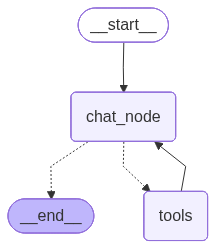

In [9]:
graph = StateGraph(ChatState)  # recreate clean graph

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile()
workflow

In [10]:
output = workflow.invoke({"messages": [HumanMessage(content="hii")]})

print(output['messages'][-1].content)

I'm happy to chat with you. What would you like to talk about or what can I help you with?


In [11]:
output = workflow.invoke({'messages':[HumanMessage(content="what is Weather of Bhiwapur")]})

print(output['messages'][-1].content)

The weather of Bhiwapur is currently 23.0°C with a mist condition and a wind speed of 12.6 km/h. The humidity is 38% and the atmospheric pressure is 1021.0 mb.


In [12]:
output = workflow.invoke({'messages': [HumanMessage(content="What is stock price of tata")]})
print(output['messages'][-1].content)

It seems that the stock price of Tata Motors is not available due to the free API rate limit. To get the accurate and up-to-date stock price, consider subscribing to a premium plan or using a different API.


# But simple Use

In [13]:
# graph = StateGraph(ChatState)  # recreate clean graph

# graph.add_node("chat_node", chat_node)
# graph.add_node("tools", tool_node)

# graph.add_edge(START, "chat_node")
# graph.add_conditional_edges("chat_node", tools_condition)
# # graph.add_edge("tools", "chat_node")
# # graph.add_edge("chat_node", END)

# workflow = graph.compile()
# workflow

In [14]:
# output = workflow.invoke({'messages':[HumanMessage(content="What is stock Price of Maruti Suzuki")]})
# # print(output['messages'][1])